In [1]:
from loss_funktion.bout_info import BOUTHESELInfo
from pathlib import Path

hesel_path = Path.cwd().resolve().parent / "simulatorer/BOUT/BOUT-HESEL" / "data"
info = BOUTHESELInfo(hesel_path)


interactive(children=(IntSlider(value=0, description='t_idx'), Output()), _dom_classes=('widget-interact',))

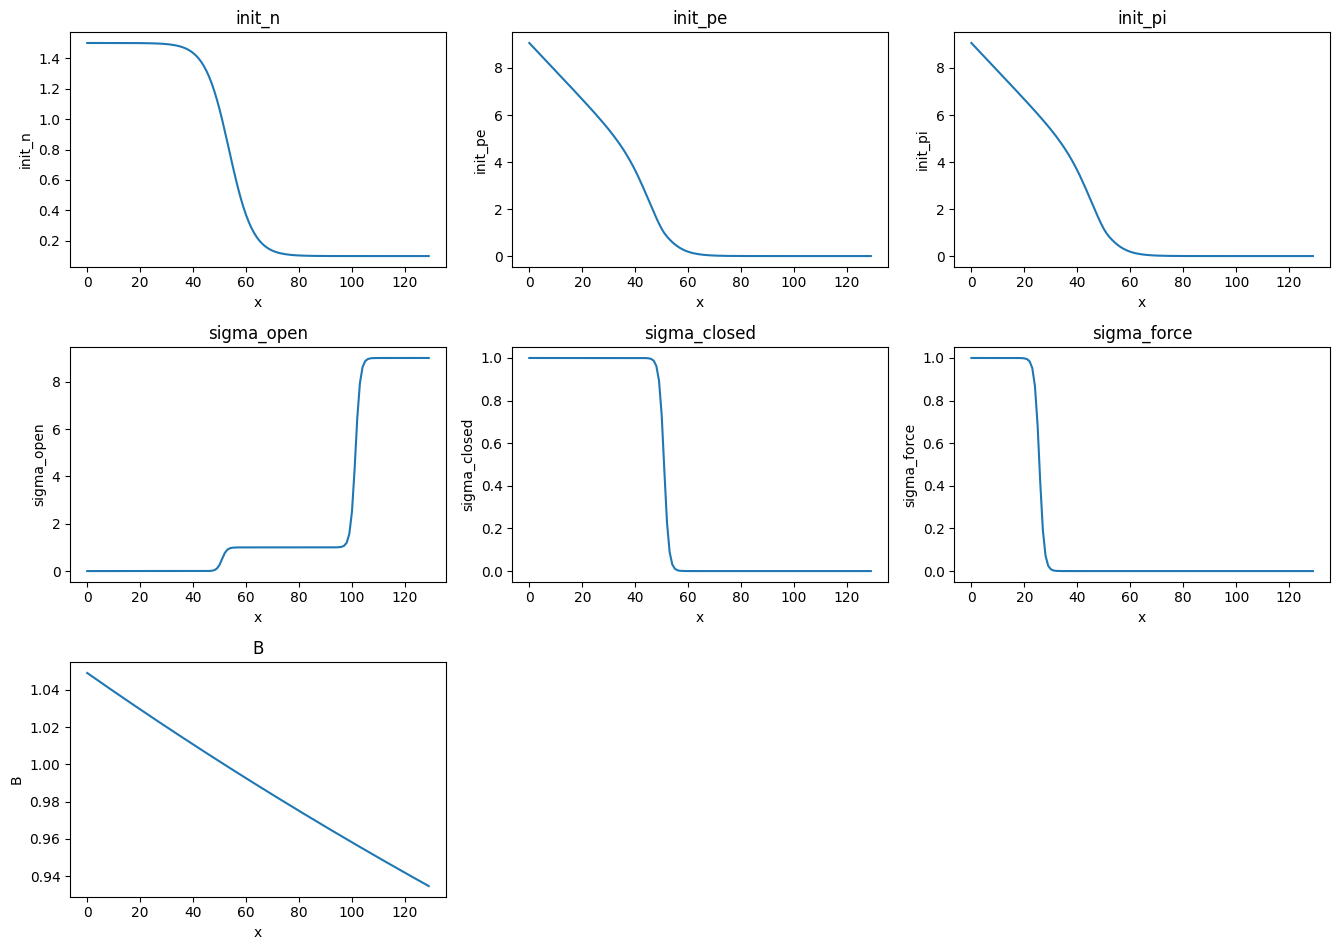

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

wanted_slider_vars = ["lnn", "lnpe", "lnpi", "vort", "phi"]
wanted_line_vars = ["init_n", "init_pe", "init_pi", "sigma_open", "sigma_closed", "sigma_force", "B"]

slider_vars = [
    name
    for name in wanted_slider_vars
    if name in info.data and np.asarray(info.data[name]).ndim >= 3
]

line_vars = [
    name
    for name in wanted_line_vars
    if name in info.data and np.asarray(info.data[name]).ndim == 1
]


def _time_image(name: str, t_idx: int):
    arr = np.asarray(info.data[name])
    t_idx = int(np.clip(t_idx, 0, arr.shape[0] - 1))
    return arr[t_idx], t_idx


def plot_slider_group(t_idx: int = 0):
    n = len(slider_vars)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.8 * cols, 3.6 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, slider_vars):
        img, t_used = _time_image(name, t_idx)
        im = ax.imshow(img, aspect="auto", origin="lower", cmap="viridis")
        ax.set_title(f"{name} @ t={t_used}")
        ax.set_xlabel("z")
        ax.set_ylabel("x")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


if slider_vars:
    t_max = max(np.asarray(info.data[name]).shape[0] - 1 for name in slider_vars)
    interact(plot_slider_group, t_idx=IntSlider(min=0, max=t_max, step=1, value=0))


if line_vars:
    n = len(line_vars)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, line_vars):
        arr = np.asarray(info.data[name])
        ax.plot(arr)
        ax.set_title(name)
        ax.set_xlabel("x")
        ax.set_ylabel(name)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

Loaded checkpoint: trained_pinn_2026-04-26_19-45-18.pt
Disse variabler kunne ikke fejlplottes (mangler i model/data eller shape mismatch): ['vort']


interactive(children=(IntSlider(value=0, description='t_idx'), Output()), _dom_classes=('widget-interact',))

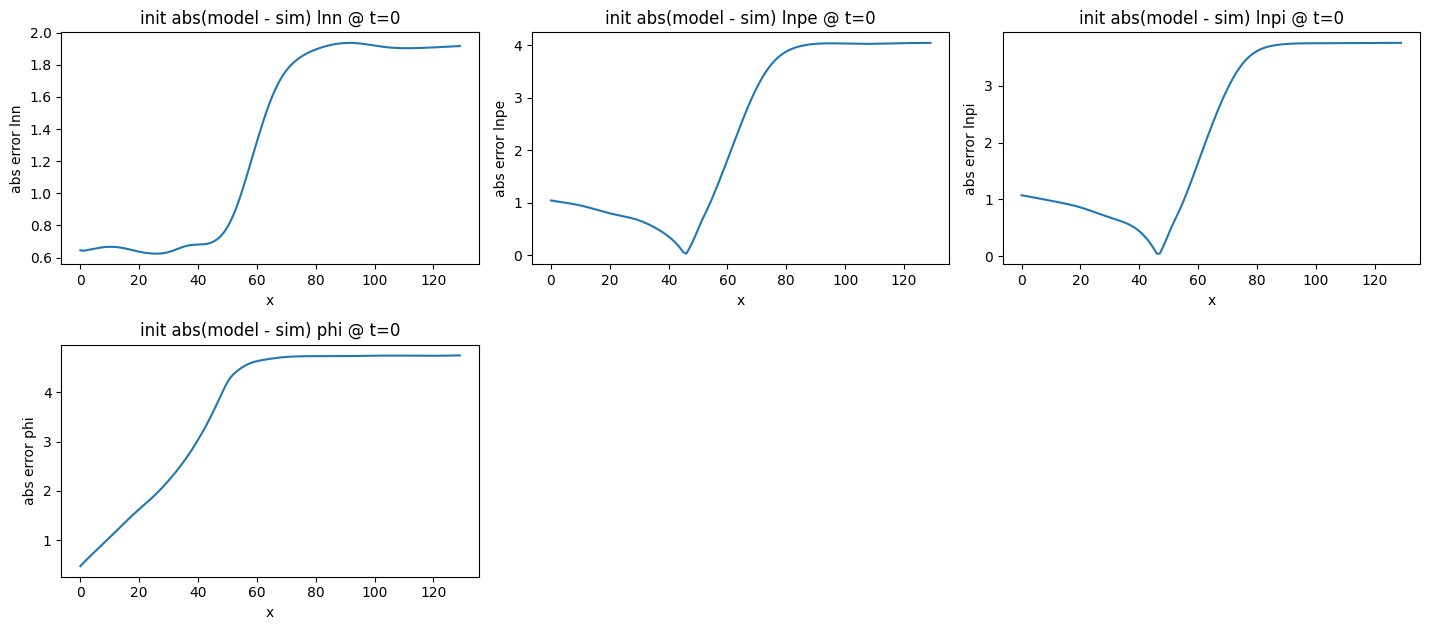

In [3]:
# Absolutfejl-plots: samme type plots, men for abs(model_prediction - sim_data)
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from ipywidgets import interact, IntSlider
from utils.model import PINN

wanted_slider_vars = ["lnn", "lnpe", "lnpi", "vort", "phi"]
wanted_init_vars = ["lnn", "lnpe", "lnpi", "vort", "phi"]

def _activation_from_name(name: str):
    activations = {
        "Tanh": torch.nn.Tanh,
        "SiLU": torch.nn.SiLU,
    }
    if name not in activations:
        raise ValueError(f"Ukendt activation i checkpoint: {name}")
    return activations[name]

def _load_latest_model_from_checkpoint():
    ckpt_dir = Path.cwd().resolve() / "data"
    checkpoints = sorted(ckpt_dir.glob("trained_pinn_*.pt"), key=lambda p: p.stat().st_mtime)
    if not checkpoints:
        raise FileNotFoundError(f"Ingen checkpoints fundet i {ckpt_dir}")

    ckpt_path = checkpoints[-1]
    checkpoint = torch.load(ckpt_path, map_location="cpu")

    serialized = checkpoint["nn_structure"]
    structure = {
        "input_size": int(serialized["input_size"]),
        "output_size": int(serialized["output_size"]),
        "output_names": tuple(serialized["output_names"]),
        "layers": [
            {
                "size": int(layer["size"]),
                "non_lin_foo": _activation_from_name(layer["non_lin_foo"]),
            }
            for layer in serialized["layers"]
        ],
    }

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = PINN(structure).to(device)
    model.load_state_dict(checkpoint["model_state_dict"] )
    model.eval()
    print(f"Loaded checkpoint: {ckpt_path.name}")
    return model, device

def _predict_model_fields(model, device, info_obj):
    nt, nx, nz = info_obj.data["lnn"].shape

    x_vals = torch.linspace(0.0, 1.0, nx, device=device)
    z_vals = torch.linspace(0.0, 1.0, nz, device=device)
    x_grid, z_grid = torch.meshgrid(x_vals, z_vals, indexing="ij")
    x_in = x_grid.reshape(-1, 1)
    z_in = z_grid.reshape(-1, 1)

    pred = {name: np.zeros((nt, nx, nz), dtype=np.float32) for name in model.output_names}

    with torch.no_grad():
        for t_idx in range(nt):
            t_value = t_idx / max(nt - 1, 1)
            t_in = torch.full_like(x_in, t_value)
            out = model(x_in, z_in, t_in)
            for name in model.output_names:
                pred[name][t_idx] = out[name].reshape(nx, nz).detach().cpu().numpy()

    return pred

model, device = _load_latest_model_from_checkpoint()
pred_data = _predict_model_fields(model, device, info)

error_data = {}
for name in wanted_slider_vars:
    if name not in pred_data:
        continue
    if name not in info.data:
        continue
    sim_arr = np.asarray(info.data[name], dtype=np.float32)
    if sim_arr.ndim < 3:
        continue
    if sim_arr.shape != pred_data[name].shape:
        continue
    error_data[name] = np.abs(pred_data[name] - sim_arr)

missing_error_vars = [name for name in wanted_slider_vars if name not in error_data]
if missing_error_vars:
    print("Disse variabler kunne ikke fejlplottes (mangler i model/data eller shape mismatch):", missing_error_vars)

def _time_image_abs(name: str, t_idx: int):
    arr = np.asarray(error_data[name])
    t_idx = int(np.clip(t_idx, 0, arr.shape[0] - 1))
    return arr[t_idx], t_idx

def plot_slider_group_abs(t_idx: int = 0):
    vars_abs = list(error_data.keys())
    n = len(vars_abs)
    if n == 0:
        print("Ingen fælles variabler til abs(model - sim)-plot.")
        return

    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.8 * cols, 3.6 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, vars_abs):
        img, t_used = _time_image_abs(name, t_idx)
        im = ax.imshow(img, aspect="auto", origin="lower", cmap="magma")
        ax.set_title(f"abs(model - sim) {name} @ t={t_used}")
        ax.set_xlabel("z")
        ax.set_ylabel("x")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

if error_data:
    t_max = max(np.asarray(error_data[name]).shape[0] - 1 for name in error_data)
    interact(plot_slider_group_abs, t_idx=IntSlider(min=0, max=t_max, step=1, value=0))

# Init-profiler af absolutfejl ved t=0, middel over z
init_error_vars = [name for name in wanted_init_vars if name in error_data]
if init_error_vars:
    n = len(init_error_vars)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.8 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, init_error_vars):
        field_t0_abs = np.asarray(error_data[name])[0]
        x_profile_abs = field_t0_abs.mean(axis=1)
        ax.plot(x_profile_abs)
        ax.set_title(f"init abs(model - sim) {name} @ t=0")
        ax.set_xlabel("x")
        ax.set_ylabel(f"abs error {name}")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=0, description='t_idx'), Output()), _dom_classes=('widget-interact',))

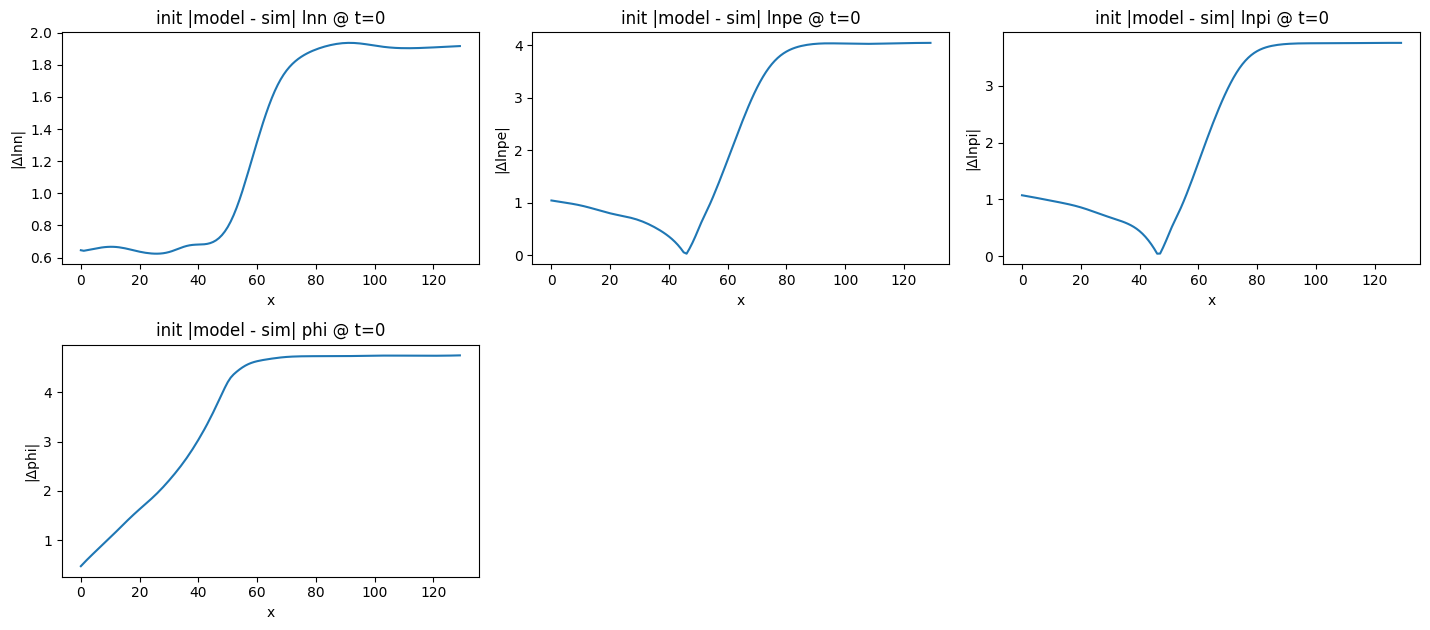

In [4]:
# Absolut fejl: |model_prediction - sim_data|
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

wanted_error_vars = ["lnn", "lnpe", "lnpi", "vort", "phi"]

if "pred_data" not in globals():
    raise RuntimeError("Kør celle 3 først, så pred_data bliver oprettet.")

common_error_vars = [
    name
    for name in wanted_error_vars
    if (name in pred_data) and (name in info.data) and (np.asarray(info.data[name]).ndim >= 3)
]

if not common_error_vars:
    print("Ingen fælles 3D-felter fundet mellem modelprediktion og sim_data.")
else:
    abs_err_data = {}
    for name in common_error_vars:
        model_arr = np.asarray(pred_data[name], dtype=np.float32)
        sim_arr = np.asarray(info.data[name], dtype=np.float32)
        nt = min(model_arr.shape[0], sim_arr.shape[0])
        nx = min(model_arr.shape[1], sim_arr.shape[1])
        nz = min(model_arr.shape[2], sim_arr.shape[2])
        abs_err_data[name] = np.abs(model_arr[:nt, :nx, :nz] - sim_arr[:nt, :nx, :nz])

    def _time_image_abs_err(name: str, t_idx: int):
        arr = abs_err_data[name]
        t_idx = int(np.clip(t_idx, 0, arr.shape[0] - 1))
        return arr[t_idx], t_idx

    def plot_slider_group_abs_err(t_idx: int = 0):
        n = len(common_error_vars)
        cols = 3
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(4.8 * cols, 3.6 * rows))
        axes = np.atleast_1d(axes).ravel()

        for ax, name in zip(axes, common_error_vars):
            img, t_used = _time_image_abs_err(name, t_idx)
            im = ax.imshow(img, aspect="auto", origin="lower", cmap="magma")
            ax.set_title(f"|model - sim| {name} @ t={t_used}")
            ax.set_xlabel("z")
            ax.set_ylabel("x")
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        for ax in axes[n:]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

    t_max = max(abs_err_data[name].shape[0] - 1 for name in common_error_vars)
    interact(plot_slider_group_abs_err, t_idx=IntSlider(min=0, max=t_max, step=1, value=0))

    # Init-profiler (t=0): middel over z af absolut fejl
    n = len(common_error_vars)
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4.8 * cols, 3.2 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, common_error_vars):
        err_t0 = abs_err_data[name][0]
        x_profile = err_t0.mean(axis=1)
        ax.plot(x_profile)
        ax.set_title(f"init |model - sim| {name} @ t=0")
        ax.set_xlabel("x")
        ax.set_ylabel(f"|Δ{name}|")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()